In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)


colors = plt.cm.tab10.colors
color_map = {
    'tt': colors[1],
    'qq': colors[5]
}

In [29]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import PchipInterpolator

def plot_simple_fill(df, color, label, sigma=0.8, npts=400):
    # sigma: smoothing width in grid points (larger = smoother, 0 = none)
    df_filtered = df[np.isclose(df['r_value'], r_target)].dropna().copy()
    if df_filtered.empty:
        return

    # Lowest cross-section per mass flattens loops/overhangs into a single line
    df_filtered['mZp_round'] = df_filtered['mZp_GeV'].round(0)
    line_data = (df_filtered.groupby('mZp_round')['xsecXBR_pb'].min()
                 .reset_index().sort_values('mZp_round'))

    x = line_data['mZp_round'].values
    y = line_data['xsecXBR_pb'].values

    # Smooth in log-space on a uniform mass grid
    xg = np.linspace(x.min(), x.max(), npts)
    logy = PchipInterpolator(x, np.log10(y))(xg)
    x = xg
    y = 10 ** gaussian_filter1d(logy, sigma=sigma, mode='nearest')

    # Extend to the y-axis if the data starts after 1500
    if x[0] > 1500.0:
        x = np.insert(x, 0, 1500.0)
        y = np.insert(y, 0, y[0])

    plt.plot(x, y, color=color, linewidth=2, linestyle='solid', label=label)
    plt.fill_between(x, y, upper_limit, color=color, alpha=0.3)


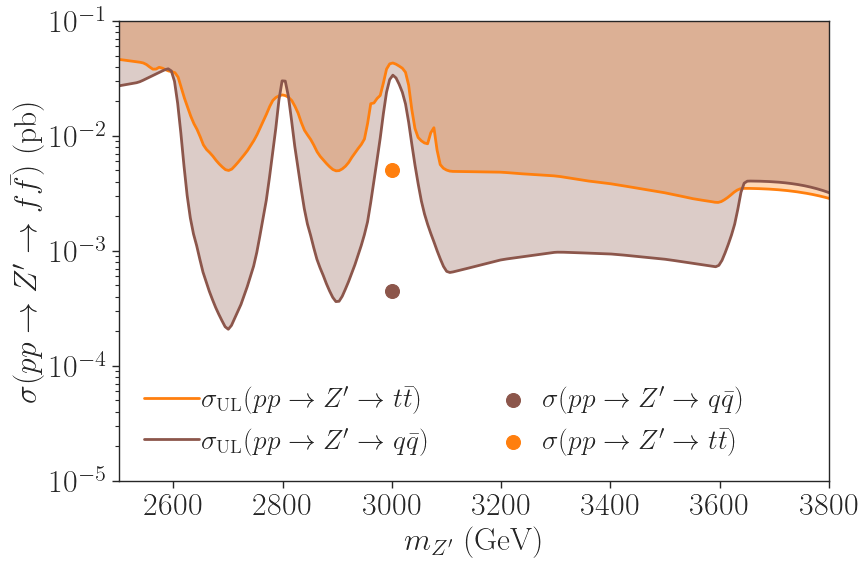

In [33]:
# Load Data
df_qq = pd.read_csv('../Recast/Zprime/Exclusion_Contours_topDom_qq.csv')
df_tt = pd.read_csv('../Recast/Zprime/Exclusion_Contours_topDom_tt.csv')

r_target = 1.0 / 1.5
upper_limit = 0.5  
target_mass = 3000 #GeV
S_qq = 4.52e-04 #GeV
S_tt = 5.02e-03 #GeV


# ---------------------------------------------------------
# Create the Final Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(9, 6))

plot_simple_fill(df_tt, color=color_map["tt"], label=r'$\sigma_{\rm UL}(p p \to Z^\prime \to t\bar{t})$')
plot_simple_fill(df_qq, color=color_map["qq"], label=r'$\sigma_{\rm UL}(p p \to Z^\prime \to q\bar{q})$')
plt.scatter([target_mass], [S_qq], color=color_map["qq"], edgecolor=color_map["qq"], 
            s=100, marker='o', zorder=4, label=r'$\sigma(p p \to Z^\prime \to q\bar{q})$')
plt.scatter([target_mass], [S_tt], color=color_map["tt"], edgecolor=color_map["tt"], 
            s=100, marker='o', zorder=4, label=r'$\sigma(p p \to Z^\prime \to t\bar{t})$')

# Formatting
plt.legend(loc='lower left', fontsize=20, framealpha=0, ncols=2,handletextpad=0.1)
plt.yscale('log')
plt.xlabel(r'$m_{Z^\prime}$ (GeV)', fontsize=23)
plt.ylabel(r'$\sigma(pp \to Z^\prime \to f\bar{f})$ (pb)', fontsize=23)

plt.xlim(2500, 3800)
plt.ylim(1e-5, 1e-1)

plt.tick_params(axis = 'both', labelsize = 23)
# plt.title(r'LHC Constraints on $Z^\prime$ Decays', fontsize=25)
plt.tight_layout()
plt.savefig('direct_searches_zprime.png', dpi=300)
plt.show()